# Fake Review Detection: Exploratory Data Analysis & Text Preprocessing

## 1. Introduction
In this notebook, we perform the initial phase of our project: investigating the "fingerprints" of fake reviews. We analyze the dataset's distribution and apply preprocessing to make the text suitable for machine learning.

---


## 2. Environment Setup & Data Loading

We start by importing necessary libraries, setting up NLTK resources, and loading the raw dataset.


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

# Constants
RANDOM_STATE = 42
DATA_PATH = '../data/raw/fake_reviews.csv'
FIGURES_DIR = "../figures"
OUTPUT_PATH = '../data/preprocessed/cleaned_reviews.csv'

# Create directories if they don't exist
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Set theme for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def setup_nltk():
    resources = ['punkt', 'stopwords', 'wordnet', 'omw-1.4']
    for r in resources:
        try:
            nltk.data.find(r)
        except LookupError:
            nltk.download(r)

setup_nltk()

print("Loading raw data...")
df = pd.read_csv(DATA_PATH)
df.rename(columns={'text_': 'review'}, inplace=True)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Loading raw data...
Dataset Dimensions: 40432 rows, 4 columns


## 3. Exploratory Data Analysis (EDA)

We investigate class balance, review lengths, and common words to understand the characteristics of fake vs. real reviews.


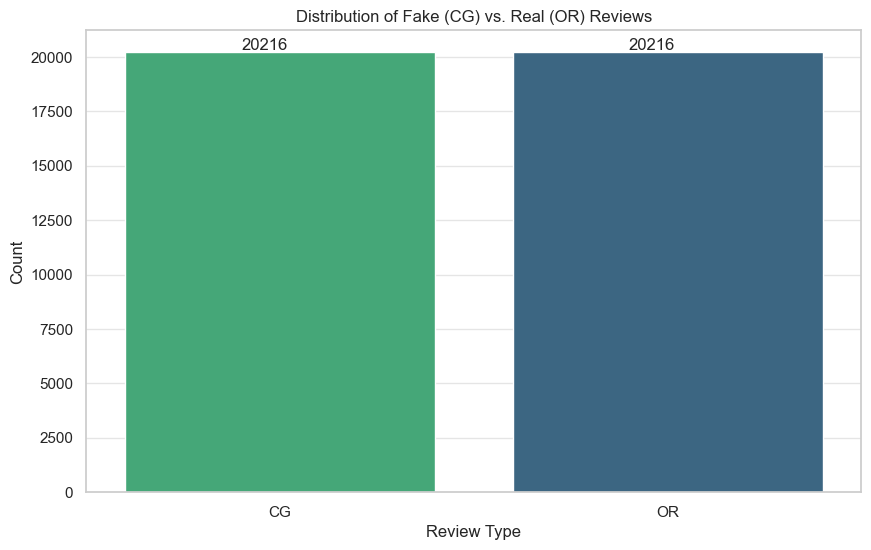

In [2]:
# 3.1. Class Balance
df['label_binary'] = df['label'].map({'CG': 1, 'OR': 0})

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=df, palette='viridis', hue='label_binary', legend=False)
plt.title("Distribution of Fake (CG) vs. Real (OR) Reviews")
plt.xlabel("Review Type")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 100))
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"))
plt.show()


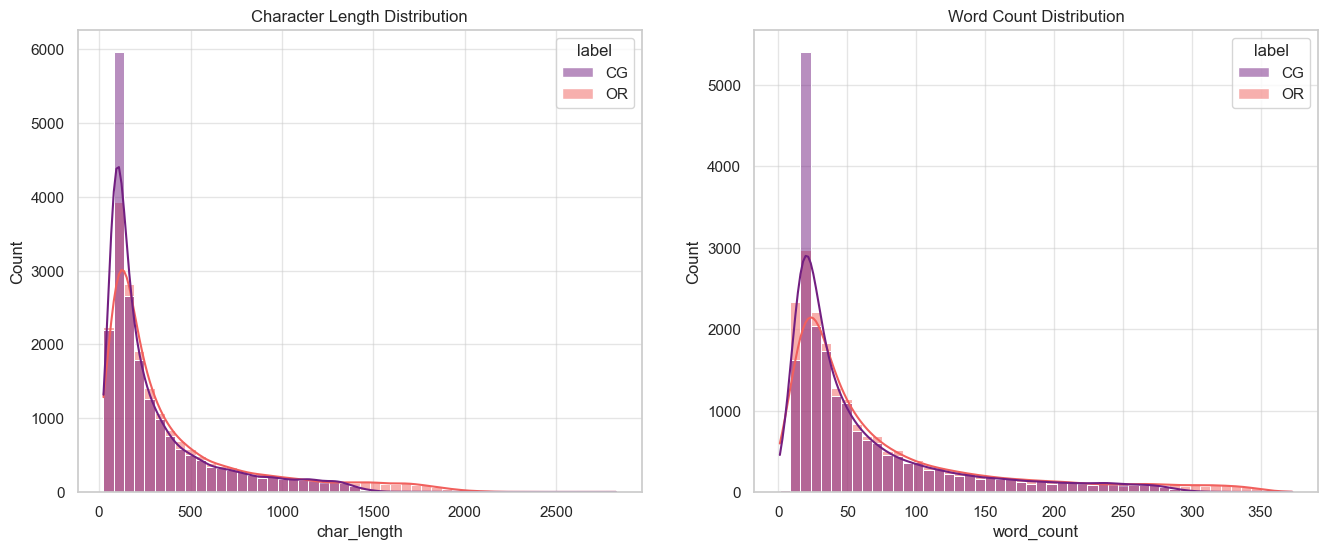

In [3]:
# 3.2. Review Length Analysis
df['char_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='char_length', hue='label', kde=True, bins=50, ax=ax1, palette='magma')
ax1.set_title("Character Length Distribution")

sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=50, ax=ax2, palette='magma')
ax2.set_title("Word Count Distribution")

plt.savefig(os.path.join(FIGURES_DIR, "length_distribution.png"))
plt.show()


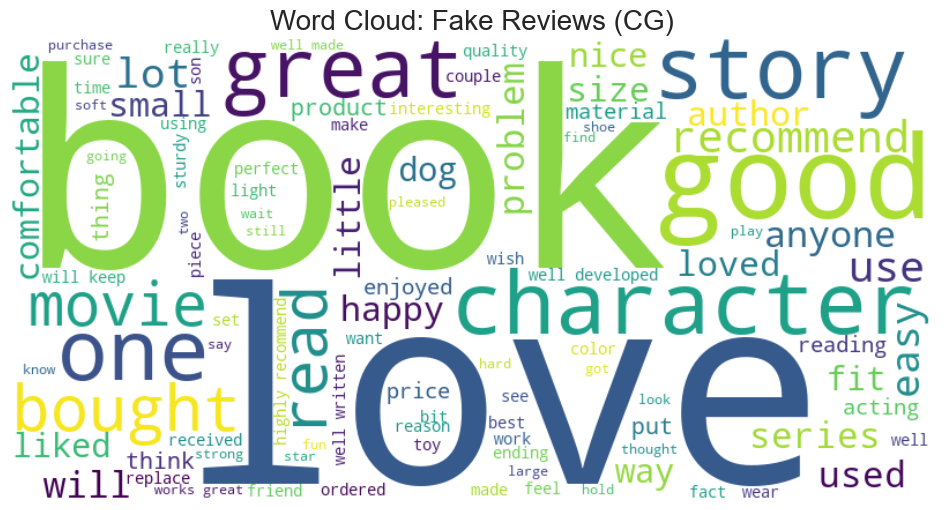

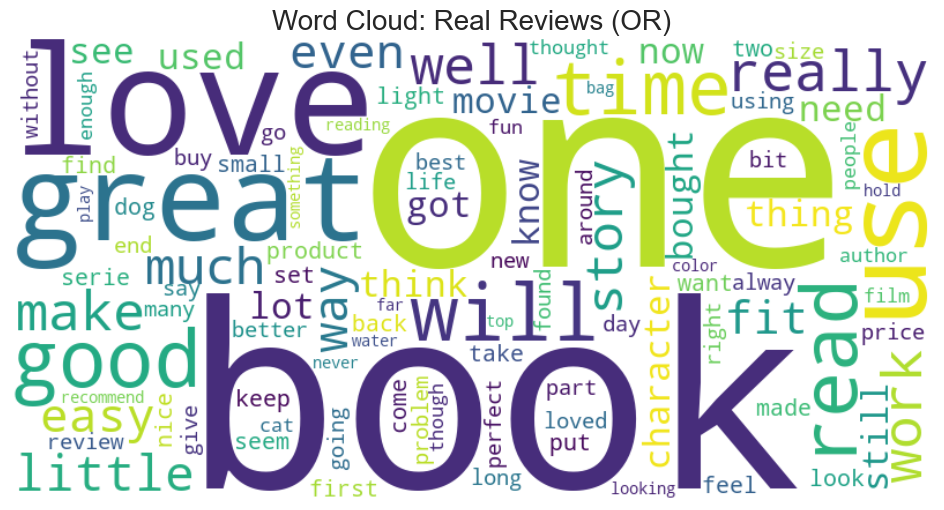

In [5]:
# 3.3. Word Clouds
def generate_wordcloud(text, title, filename):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.savefig(os.path.join(FIGURES_DIR, filename))
    plt.show()

fake_text = " ".join(df[df['label'] == 'CG']['review'].astype(str))
real_text = " ".join(df[df['label'] == 'OR']['review'].astype(str))

generate_wordcloud(fake_text, "Word Cloud: Fake Reviews (CG)", "wordcloud_fake.png")
generate_wordcloud(real_text, "Word Cloud: Real Reviews (OR)", "wordcloud_real.png")


## 4. Text Preprocessing

We apply a cleaning pipeline: lowercasing, noise removal, tokenization, stopword removal, and lemmatization.


In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

print("Starting preprocessing...")
tqdm.pandas()
df['cleaned_review'] = df['review'].progress_apply(clean_text)

# Preview results
df[['review', 'cleaned_review']].head()


Starting preprocessing...


100%|██████████| 40432/40432 [00:58<00:00, 685.64it/s] 


,review,cleaned_review
0,"Love this! Well made, sturdy, and very comfor...",love well made sturdy comfortable love pretty
1,"love it, a great upgrade from the original. I...",love great upgrade original mine couple year
2,This pillow saved my back. I love the look and...,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",missing information use great product price
4,Very nice set. Good quality. We have had the s...,nice set good quality set two month


## 5. Saving Results

We save the cleaned dataset as the foundation for our feature extraction and model training.


In [8]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Successfully saved {len(df)} preprocessed reviews to: {OUTPUT_PATH}")


Successfully saved 40432 preprocessed reviews to: ../data/preprocessed/cleaned_reviews.csv


## 5. Text Preprocessing Pipeline
To make the text suitable for machine learning, we need to:
1.  **Lowerization**: Convert to lowercase for uniformity.
2.  **Noise Removal**: Remove URLs, numbers, and special characters.
3.  **Tokenization**: Split text into individual words.
4.  **Stopword Removal**: Remove common words (e.g., 'the', 'is') that don't carry significant meaning.
5.  **Lemmatization**: Reduce words to their base/dictionary form (e.g., 'running' -> 'run').


## 6. Saving the Results
The cleaned dataset will serve as the foundation for our feature extraction (TF-IDF/Embeddings) and model training.
